<a href="https://colab.research.google.com/github/MedushaThiru/Internship---DecodeLabs/blob/main/Project2_EDA_DecodeLabs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv('Cleaned_Dataset_Project1.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Calculated_Total
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04


Basic statistics (mean, median, count)

In [2]:
df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].describe()

,Quantity,UnitPrice,TotalPrice,ItemsInCart
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,1053.968300,5.485000
std,1.407557,197.177146,819.856558,2.281983
min,1.000000,11.390000,11.390000,1.000000
25%,2.000000,186.062500,410.520000,4.000000
50%,3.000000,364.210000,823.615000,5.000000
75%,4.000000,521.570000,1578.475000,7.000000
max,5.000000,699.930000,3456.400000,10.000000


Distribution check (is it skewed?)

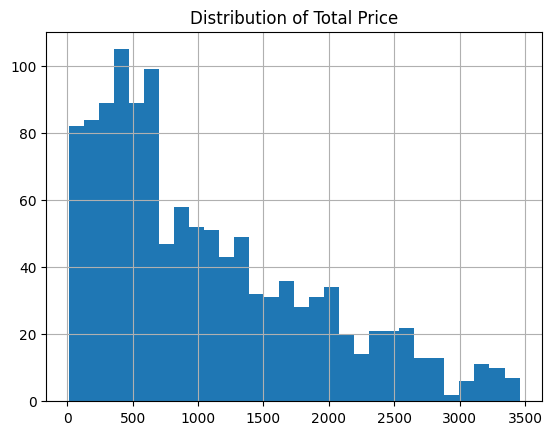

In [3]:
import matplotlib.pyplot as plt

df['TotalPrice'].hist(bins=30)
plt.title('Distribution of Total Price')
plt.show()

Outlier detection (IQR method)

In [4]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)]
print("Number of outliers:", len(outliers))

Number of outliers: 8


Trends over time

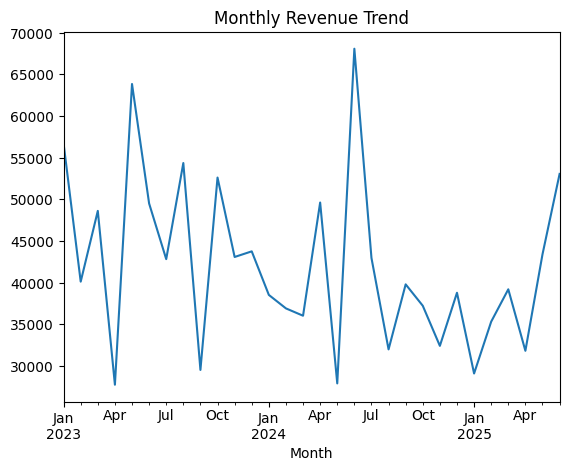

In [5]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
monthly_sales.plot(kind='line', title='Monthly Revenue Trend')
plt.show()

Category breakdowns

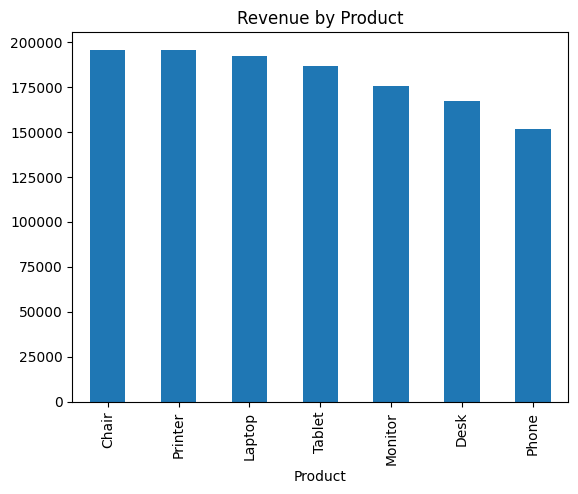

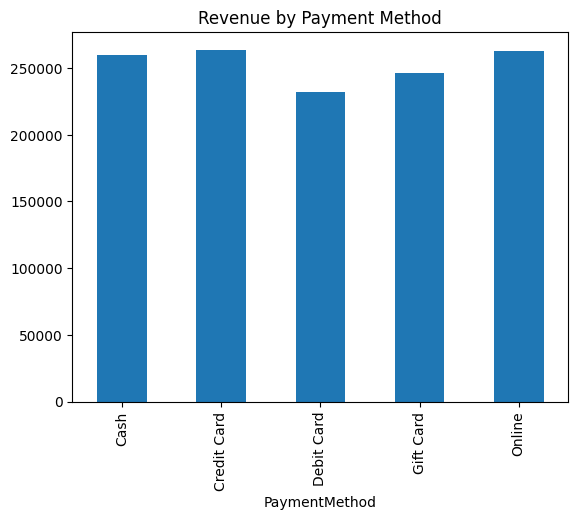

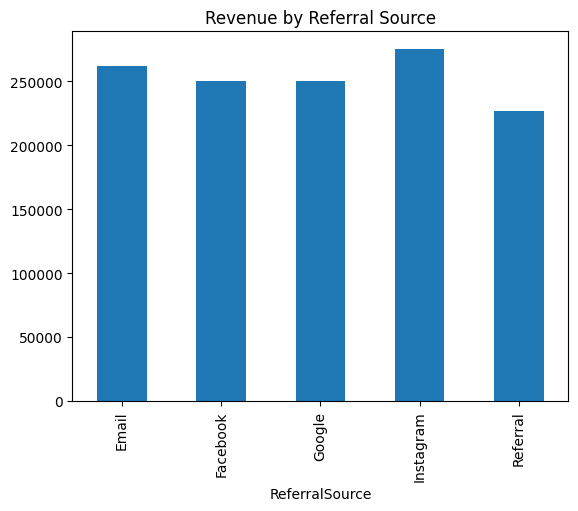

In [6]:
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).plot(kind='bar', title='Revenue by Product')
plt.show()

df.groupby('PaymentMethod')['TotalPrice'].sum().plot(kind='bar', title='Revenue by Payment Method')
plt.show()

df.groupby('ReferralSource')['TotalPrice'].sum().plot(kind='bar', title='Revenue by Referral Source')
plt.show()

Correlation

In [7]:
df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].corr()

,Quantity,UnitPrice,TotalPrice,ItemsInCart
Quantity,1.000000,0.014553,0.615251,0.650061
UnitPrice,0.014553,1.000000,0.717081,0.000602
TotalPrice,0.615251,0.717081,1.000000,0.392540
ItemsInCart,0.650061,0.000602,0.392540,1.000000


In [8]:
print(df['TotalPrice'].describe())
print(df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False))

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64
Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


***This analysis explored a 1,200-row e-commerce orders dataset to uncover patterns in sales and product performance. The TotalPrice distribution is right-skewed, with a mean of $1,053.97 but a median of only $823.62, indicating that a smaller number of high-value orders pull the average upward; orders above approximately $3,330 (the IQR upper bound) are statistical outliers and warrant closer review as potential bulk or high-value customers. Revenue is fairly evenly distributed across products, with Chairs ($195,620) and Printers ($195,613) generating the highest revenue, while Phones ($151,722) generated the least. Given this, the business should investigate the high-value outlier orders for VIP customer or bulk-buyer opportunities, and consider whether marketing/inventory focus on Chairs and Printers — the top revenue drivers — could be expanded further.***